In [10]:
using CSV
using DataFrames
using Plots
using Statistics

In [11]:
function plot_converge(fname)
    df = CSV.read(fname, DataFrame)
    p = plot(df.iter, df.rho, yscale=:log10, xlabel="Iteration", ylabel="ρ", title="NACA0012", legend=false)
    display(p)
end

plot_converge (generic function with 1 method)

In [12]:
function extract_cl(fname, tol=1e-5)
    raw = CSV.read(fname, DataFrame)

    if "cl_v" in names(raw)
        cl = raw.cl_p .+ raw.cl_v
    else
        cl = raw.cl_p
    end

    cl_last = cl[end]

    if abs(cl_last - mean(cl[end-19:end])) > tol
        @warn "CL value may not have converged: $fname"
    end

    return cl_last
end

extract_cl (generic function with 2 methods)

In [13]:
aoa = [0, 2, 4, 6, 8, 12, 16, 18];

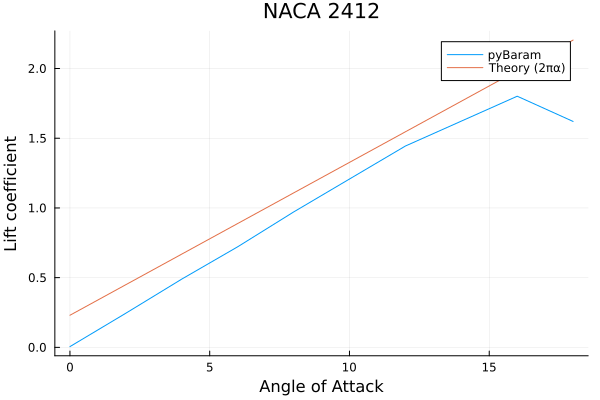

┌ Warning: CL value may not have converged: /home/seawhan/Github/aerodynamic-experiment/naca0012/results/../aoa16/force_airfoil.csv
└ @ Main /home/seawhan/Github/aerodynamic-experiment/naca0012/results/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W1sdnNjb2RlLXJlbW90ZQ==.jl:13
┌ Warning: CL value may not have converged: /home/seawhan/Github/aerodynamic-experiment/naca0012/results/../aoa18/force_airfoil.csv
└ @ Main /home/seawhan/Github/aerodynamic-experiment/naca0012/results/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W1sdnNjb2RlLXJlbW90ZQ==.jl:13


"/home/seawhan/Github/aerodynamic-experiment/naca0012/results/cl.png"

In [14]:
# Extract CL values for each angle of attack
cl_naca0012 = [extract_cl(joinpath(@__DIR__, "..", "aoa$(a)", "force_airfoil.csv"), 5e-4) for a in aoa]

# Convert aoa (degrees) to radians and compute theory line (2π * α)
alpha_rad = (aoa .+ 2.1) .* (pi/180)  # broadcast to handle arrays
theory = 2pi .* alpha_rad

# Plot with Plots.jl
plot_naca2412 = plot(aoa, cl_naca0012, label="pyBaram", xlabel="Angle of Attack", ylabel="Lift coefficient",
         legend=:topright, grid=true)
plot!(plot_naca2412, aoa, theory, label="Theory (2πα)")
title!(plot_naca2412, "NACA 2412")
display(plot_naca2412)
savefig(plot_naca2412, "cl.png")